# **Importing Libraries**

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **Loading Dataset**

In [10]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("------------------ Dataset Information ------------------")
print(df.info())
print("\n------------------ Summary Statistics ------------------")
print(df.describe().T[['min', 'max', 'mean']])

# Converting target to binary classification (0 = Average/Poor, 1 = Good)
df['is_good'] = (df['quality'] >= 6).astype(int)

print("\n--- Target Class Distribution ---")
print(df['is_good'].value_counts(normalize=True))

------------------ Dataset Information ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

------------------ Summary Statistics ------------------
     

# **Exploratory Data Analysis (EDA)**

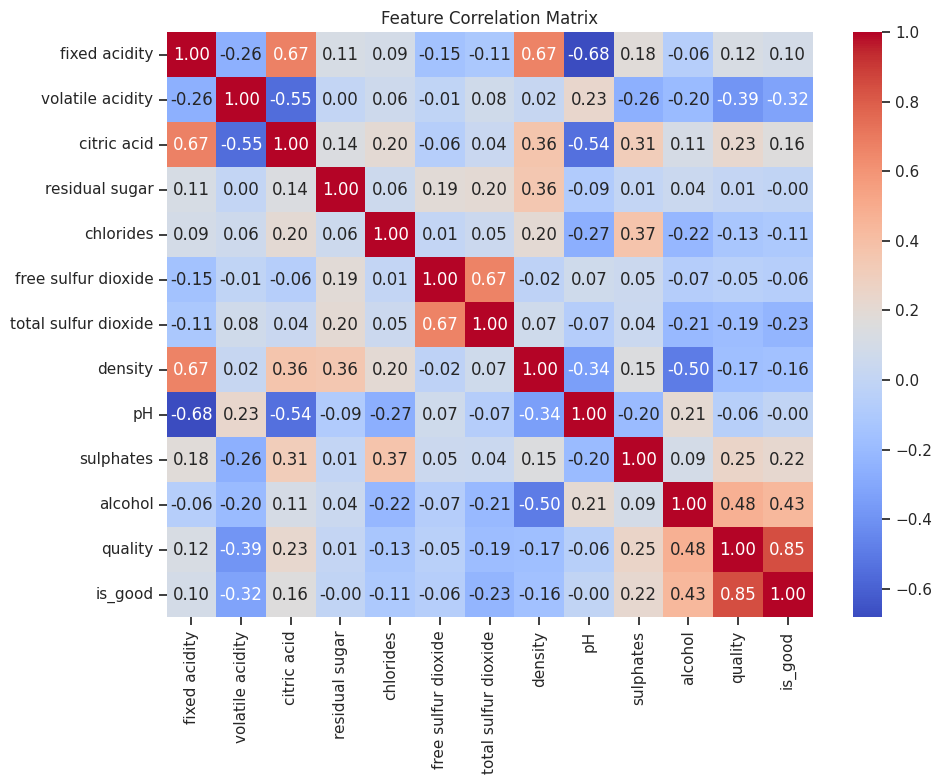

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# **Data Preprocessing & Scaling**

In [13]:
x = df.drop(columns=['quality', 'is_good'])
y = df['is_good']

# Split data: 80% training, 20% testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# **Model Training and Evaluation**


================ Logistic Regression ================
Accuracy: 0.7406

Classification Report:
              precision    recall  f1-score   support

Bad/Avg Wine       0.71      0.74      0.73       149
   Good Wine       0.77      0.74      0.75       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320



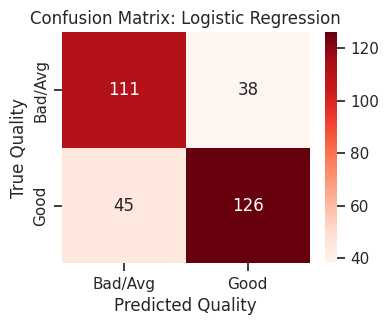




================ K-Nearest Neighbors (KNN) ================
Accuracy: 0.7531

Classification Report:
              precision    recall  f1-score   support

Bad/Avg Wine       0.73      0.74      0.74       149
   Good Wine       0.77      0.77      0.77       171

    accuracy                           0.75       320
   macro avg       0.75      0.75      0.75       320
weighted avg       0.75      0.75      0.75       320



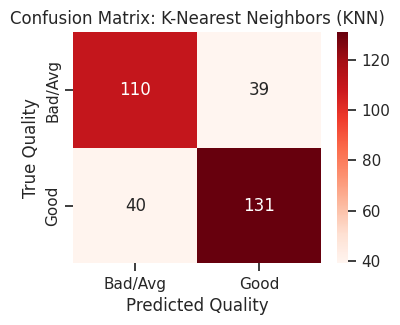




================ Decision Tree ================
Accuracy: 0.7281

Classification Report:
              precision    recall  f1-score   support

Bad/Avg Wine       0.70      0.72      0.71       149
   Good Wine       0.75      0.73      0.74       171

    accuracy                           0.73       320
   macro avg       0.73      0.73      0.73       320
weighted avg       0.73      0.73      0.73       320



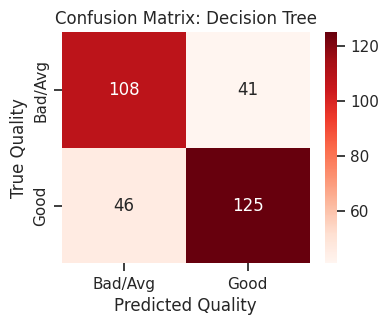

In [14]:
model_accuracies = {}
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42)
}

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    model_accuracies[name] = acc

    print(f"\n================ {name} ================")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Bad/Avg Wine', 'Good Wine']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Bad/Avg', 'Good'], yticklabels=['Bad/Avg', 'Good'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('True Quality')
    plt.xlabel('Predicted Quality')
    plt.show()
    print("\n")

# **Final Model Comparison Chart**

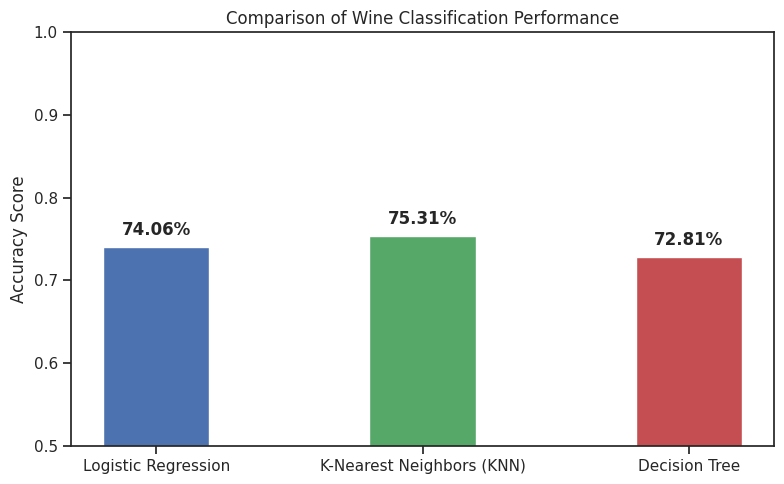

In [15]:
plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = plt.bar(model_accuracies.keys(), model_accuracies.values(), color=colors, width=0.4)

plt.ylabel('Accuracy Score')
plt.title('Comparison of Wine Classification Performance')
plt.ylim(0.5, 1.0) # Adjusted baseline since accuracies will be realistic

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()